In [1]:
import numpy as np
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from scipy.optimize import minimize
from sklearn.metrics import log_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from pathlib import Path
from allium_cepa_classifier.config.training_config import TrainingConfig

config = TrainingConfig()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
WEIGHTS_PATH = config.model_path / "classifier_efficientNetB1_20E.pt"

def load_classifier(weights_path: Path, device: torch.device):
    ckpt = torch.load(weights_path, map_location=device)

    model = timm.create_model("efficientnet_b2", pretrained=False)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.LeakyReLU(negative_slope=0.2),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.LeakyReLU(negative_slope=0.2),
        nn.Dropout(0.2),
        nn.Linear(256, 128),
        nn.LeakyReLU(negative_slope=0.2),
        nn.Linear(128, ckpt["num_classes"]),
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()
    return model, ckpt

model, ckpt = load_classifier(WEIGHTS_PATH, DEVICE)
print(f"Loaded classifier from {WEIGHTS_PATH}")
print(f"num_classes={ckpt['num_classes']}, image_size={ckpt['image_size']}")

Loaded classifier from /home/nicolas/Documentos/UTN/INA/allium_cepa_automation/src/allium_cepa_classifier/models/weights/classifier_efficientNetB1_20E.pt
num_classes=2, image_size=(260, 260)


In [3]:
IMAGE_SIZE    = ckpt["image_size"]
IMAGENET_MEAN = ckpt["imagenet_mean"]
IMAGENET_STD  = ckpt["imagenet_std"]

eval_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_dataset = datasets.ImageFolder(
    config.binary_classifier_crops_dir / "validation",
    transform=eval_transforms,
)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
print("Class mapping:", val_dataset.class_to_idx)
print(f"Validation samples: {len(val_dataset)}")

Class mapping: {'mitosis': 0, 'no_mitosis': 1}
Validation samples: 7759


In [5]:
all_logits = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        logits = model(images)          # raw logits, shape (B, 2)
        all_logits.append(logits.cpu().numpy())
        all_labels.append(labels.numpy())

all_logits = np.concatenate(all_logits, axis=0)   # (N, 2)
all_labels = np.concatenate(all_labels, axis=0)   # (N,)
print(f"Collected {len(all_labels)} validation samples")

Collected 7759 validation samples


In [6]:
NUM_CLASSES = all_logits.shape[1]

def vector_scale_loss(temp_vector: np.ndarray) -> float:
    scaled = all_logits / temp_vector
    shifted = scaled - scaled.max(axis=1, keepdims=True)
    exp_    = np.exp(shifted)
    probs   = exp_ / exp_.sum(axis=1, keepdims=True)
    return log_loss(all_labels, probs)

result = minimize(
    vector_scale_loss,
    x0=np.ones(NUM_CLASSES),
    bounds=[(0.01, 10.0)] * NUM_CLASSES,
    method="L-BFGS-B",
)
optimal_T = result.x
print(f"Optimal temperature vector: {optimal_T}")
print(f"  mitosis (class 0) T={optimal_T[0]:.4f}")
print(f"  no_mitosis (class 1) T={optimal_T[1]:.4f}")

Optimal temperature vector: [         10     0.88646]
  mitosis (class 0) T=10.0000
  no_mitosis (class 1) T=0.8865


In [7]:
class CalibratedClassifier(nn.Module):
    """Wraps the base classifier, applying per-class temperature scaling on logits."""

    def __init__(self, base_model: nn.Module, temperature: np.ndarray):
        super().__init__()
        self.base_model  = base_model
        self.temperature = nn.Parameter(
            torch.tensor(temperature, dtype=torch.float32),
            requires_grad=False,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        logits = self.base_model(x)
        scaled = logits / self.temperature
        return torch.softmax(scaled, dim=1)

    def get_temperature(self) -> np.ndarray:
        return self.temperature.cpu().numpy()


calibrated_model = CalibratedClassifier(model, optimal_T).to(DEVICE)
calibrated_model.eval()
print("CalibratedClassifier built.")

CalibratedClassifier built.


Original ECE:   0.0390
Calibrated ECE: 0.0143


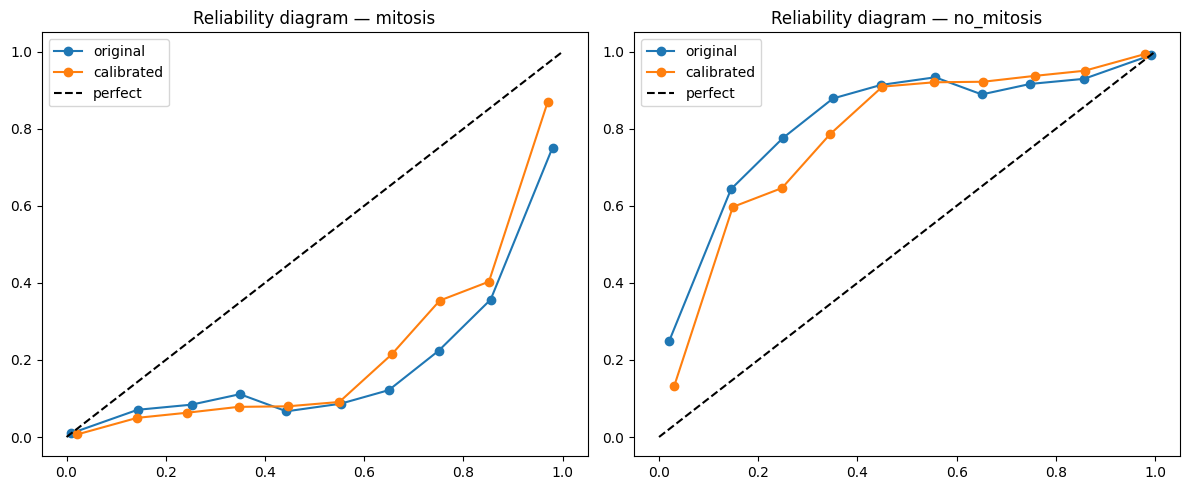

In [8]:
def get_probs(mdl, loader, device):
    all_probs, all_true = [], []
    with torch.no_grad():
        for images, labels in loader:
            probs = mdl(images.to(device)).cpu().numpy()
            all_probs.append(probs)
            all_true.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_true)

def ece(probs, labels, n_bins=10):
    confidences = probs.max(axis=1)
    preds       = probs.argmax(axis=1)
    correct     = preds == labels
    bins        = np.linspace(0, 1, n_bins + 1)
    ece_val     = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences >= lo) & (confidences < hi)
        if mask.sum() == 0:
            continue
        acc  = correct[mask].mean()
        conf = confidences[mask].mean()
        ece_val += mask.sum() / len(labels) * abs(acc - conf)
    return ece_val

class RawSoftmaxWrapper(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        return torch.softmax(self.m(x), dim=1)

orig_probs, true_labels = get_probs(RawSoftmaxWrapper(model).to(DEVICE).eval(), val_loader, DEVICE)
cal_probs,  _           = get_probs(calibrated_model, val_loader, DEVICE)

print(f"Original ECE:   {ece(orig_probs, true_labels):.4f}")
print(f"Calibrated ECE: {ece(cal_probs,  true_labels):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for cls_idx, cls_name in enumerate(["mitosis", "no_mitosis"]):
    ax = axes[cls_idx]
    for probs, label in [(orig_probs, "original"), (cal_probs, "calibrated")]:
        binary_true  = (true_labels == cls_idx).astype(int)
        cls_probs    = probs[:, cls_idx]
        frac_pos, mean_pred = calibration_curve(binary_true, cls_probs, n_bins=10)
        ax.plot(mean_pred, frac_pos, marker="o", label=label)
    ax.plot([0, 1], [0, 1], "k--", label="perfect")
    ax.set_title(f"Reliability diagram — {cls_name}")
    ax.legend()
plt.tight_layout()
plt.show()

In [9]:
save_path = config.model_path / "classifier_calibrated.pt"
torch.save({
    "model_state_dict": calibrated_model.state_dict(),
    "temperature":      optimal_T.tolist(),
    "num_classes":      NUM_CLASSES,
    "image_size":       IMAGE_SIZE,
    "class_to_idx":     val_dataset.class_to_idx,
    "imagenet_mean":    IMAGENET_MEAN,
    "imagenet_std":     IMAGENET_STD,
}, save_path)
print(f"Saved: {save_path}")

# Sanity check
ckpt_check = torch.load(save_path, map_location="cpu")
assert "temperature" in ckpt_check
assert len(ckpt_check["temperature"]) == 2
print("Sanity check passed.")

Saved: /home/nicolas/Documentos/UTN/INA/allium_cepa_automation/src/allium_cepa_classifier/models/weights/classifier_calibrated.pt
Sanity check passed.
